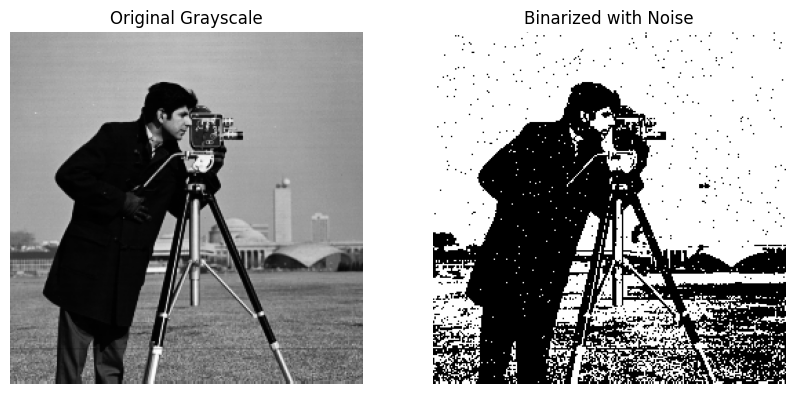

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# Read the image using OpenCV (Grayscale)
# Make sure 'cameraman.png' is in the same directory as your notebook
img_path = 'cameraman.png'
# Fallback to creating a dummy image if cameraman isn't found for testing
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    print(f"Could not load {img_path}. Creating a dummy shape image.")
    img = np.zeros((256, 256), dtype=np.uint8)
    img[50:200, 50:200] = 255
    img[100:150, 100:150] = 0

# 1. Binarize the image (Thresholding)
binary_img = (img > 127).astype(np.uint8)

# 2. Add Salt & Pepper noise
noisy_binary_img = binary_img.copy()
prob = 0.02 # 2% noise
noise_matrix = np.random.rand(*noisy_binary_img.shape)
noisy_binary_img[noise_matrix < (prob / 2)] = 0      # Pepper
noisy_binary_img[noise_matrix > 1 - (prob / 2)] = 1  # Salt

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Grayscale")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Binarized with Noise")
plt.imshow(noisy_binary_img, cmap='gray')
plt.axis('off')
plt.show()

Structuring Element (Kernel):
[[1 1 1]
 [1 1 1]
 [1 1 1]]


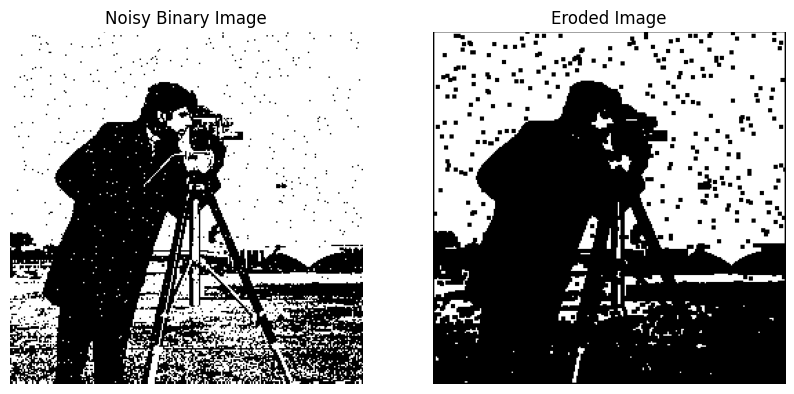

In [5]:
# Define a 3x3 Structuring Element (Kernel)
kernel_size = 3
kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)

print("Structuring Element (Kernel):")
print(kernel)

def custom_erode(image, kernel):
    # Get dimensions
    k_h, k_w = kernel.shape
    img_h, img_w = image.shape
    
    # Padding to handle edges
    pad_h, pad_w = k_h // 2, k_w // 2
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    
    eroded_img = np.zeros_like(image)
    
    # Basic Python loops to slide the window
    for i in range(img_h):
        for j in range(img_w):
            # Extract the region of interest
            roi = padded_img[i:i+k_h, j:j+k_w]
            # If all pixels under the kernel's 1s are 1, output is 1; else 0
            if np.sum(roi * kernel) == np.sum(kernel):
                eroded_img[i, j] = 1
                
    return eroded_img

eroded_img = custom_erode(noisy_binary_img, kernel)

# Display Intermediate Steps
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Noisy Binary Image")
plt.imshow(noisy_binary_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Eroded Image")
plt.imshow(eroded_img, cmap='gray')
plt.axis('off')
plt.show()

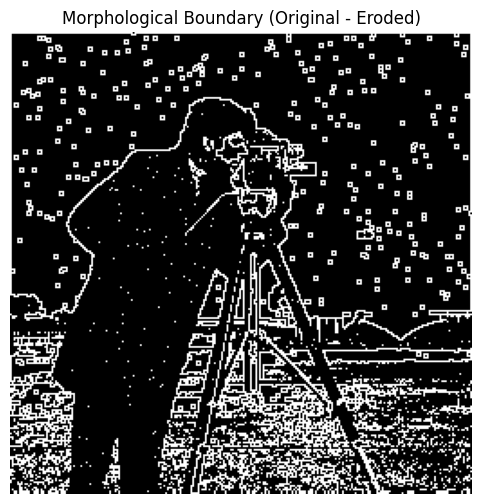

In [6]:
# Boundary = Original Binary - Eroded Binary
morphological_boundary = noisy_binary_img - eroded_img

plt.figure(figsize=(6, 6))
plt.title("Morphological Boundary (Original - Eroded)")
plt.imshow(morphological_boundary, cmap='gray')
plt.axis('off')
plt.show()

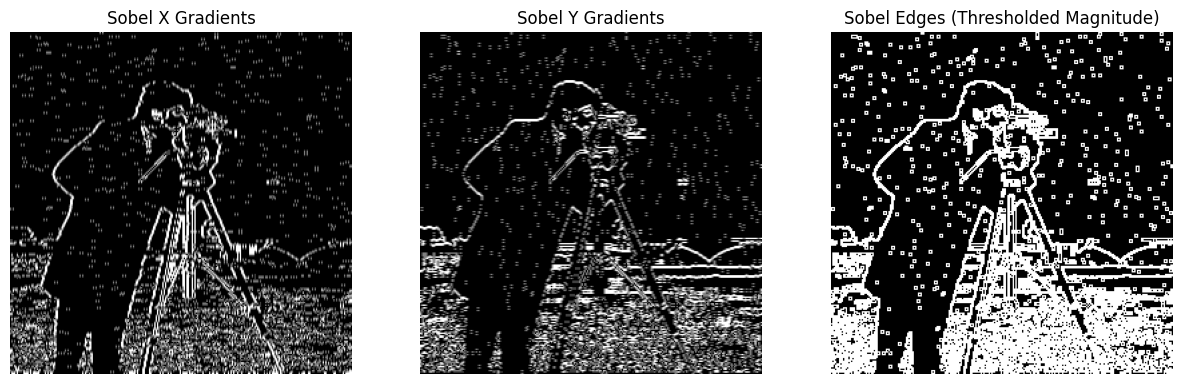

In [7]:
# Define 2D Convolution for Edge Detection
def custom_convolve(image, kernel):
    k_h, k_w = kernel.shape
    img_h, img_w = image.shape
    pad_h, pad_w = k_h // 2, k_w // 2
    
    # Pad image (using edge values to prevent harsh borders)
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge').astype(np.float32)
    output = np.zeros((img_h, img_w), dtype=np.float32)
    
    for i in range(img_h):
        for j in range(img_w):
            roi = padded_img[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(roi * kernel)
            
    return output

# Sobel Kernels
Kx = np.array([[-1, 0, 1], 
               [-2, 0, 2], 
               [-1, 0, 1]], dtype=np.float32)

Ky = np.array([[ 1,  2,  1], 
               [ 0,  0,  0], 
               [-1, -2, -1]], dtype=np.float32)

# Apply Convolutions
# Note: we use the noisy_binary_img scaled to 0-255 for better gradient visualization
sobel_x = custom_convolve(noisy_binary_img * 255.0, Kx)
sobel_y = custom_convolve(noisy_binary_img * 255.0, Ky)

# Magnitude and Direction (Direction will be used for Canny next)
sobel_magnitude = np.hypot(sobel_x, sobel_y)
sobel_magnitude = (sobel_magnitude / sobel_magnitude.max()) * 255.0
theta = np.arctan2(sobel_y, sobel_x)

# Simple threshold for final Sobel Edge map
sobel_edges = (sobel_magnitude > 50).astype(np.uint8)

# Display Intermediate Steps
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Sobel X Gradients")
plt.imshow(np.abs(sobel_x), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Sobel Y Gradients")
plt.imshow(np.abs(sobel_y), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Sobel Edges (Thresholded Magnitude)")
plt.imshow(sobel_edges, cmap='gray')
plt.axis('off')
plt.show()

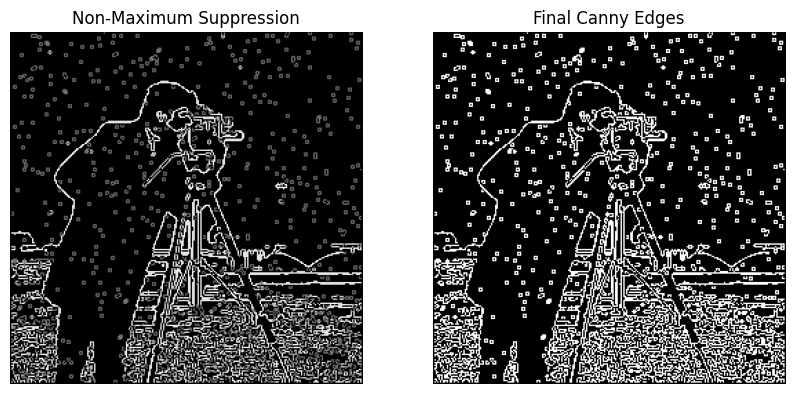

In [8]:
def non_max_suppression(magnitude, theta):
    img_h, img_w = magnitude.shape
    Z = np.zeros((img_h, img_w), dtype=np.float32)
    angle = theta * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, img_h - 1):
        for j in range(1, img_w - 1):
            q = 255
            r = 255
            
            # Angle 0
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = magnitude[i, j+1]
                r = magnitude[i, j-1]
            # Angle 45
            elif (22.5 <= angle[i,j] < 67.5):
                q = magnitude[i+1, j-1]
                r = magnitude[i-1, j+1]
            # Angle 90
            elif (67.5 <= angle[i,j] < 112.5):
                q = magnitude[i+1, j]
                r = magnitude[i-1, j]
            # Angle 135
            elif (112.5 <= angle[i,j] < 157.5):
                q = magnitude[i-1, j-1]
                r = magnitude[i+1, j+1]

            if (magnitude[i,j] >= q) and (magnitude[i,j] >= r):
                Z[i,j] = magnitude[i,j]
            else:
                Z[i,j] = 0
    return Z

def threshold_and_hysteresis(img, low_thresh_ratio=0.05, high_thresh_ratio=0.15):
    high_threshold = img.max() * high_thresh_ratio
    low_threshold = high_threshold * low_thresh_ratio
    
    img_h, img_w = img.shape
    res = np.zeros((img_h, img_w), dtype=np.uint8)
    
    weak = np.uint8(50)
    strong = np.uint8(255)
    
    strong_i, strong_j = np.where(img >= high_threshold)
    weak_i, weak_j = np.where((img <= high_threshold) & (img >= low_threshold))
    
    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak
    
    # Hysteresis (Linking weak edges to strong ones)
    for i in range(1, img_h-1):
        for j in range(1, img_w-1):
            if res[i,j] == weak:
                if (res[i+1, j-1] == strong or res[i+1, j] == strong or res[i+1, j+1] == strong
                    or res[i, j-1] == strong or res[i, j+1] == strong
                    or res[i-1, j-1] == strong or res[i-1, j] == strong or res[i-1, j+1] == strong):
                    res[i, j] = strong
                else:
                    res[i, j] = 0
    return res

# Apply Canny steps
nms_result = non_max_suppression(sobel_magnitude, theta)
canny_edges = threshold_and_hysteresis(nms_result, low_thresh_ratio=0.05, high_thresh_ratio=0.15)
# Convert to 0 and 1 for consistency
canny_edges = (canny_edges == 255).astype(np.uint8)

# Display Intermediate Steps
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Non-Maximum Suppression")
plt.imshow(nms_result, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Final Canny Edges")
plt.imshow(canny_edges, cmap='gray')
plt.axis('off')
plt.show()

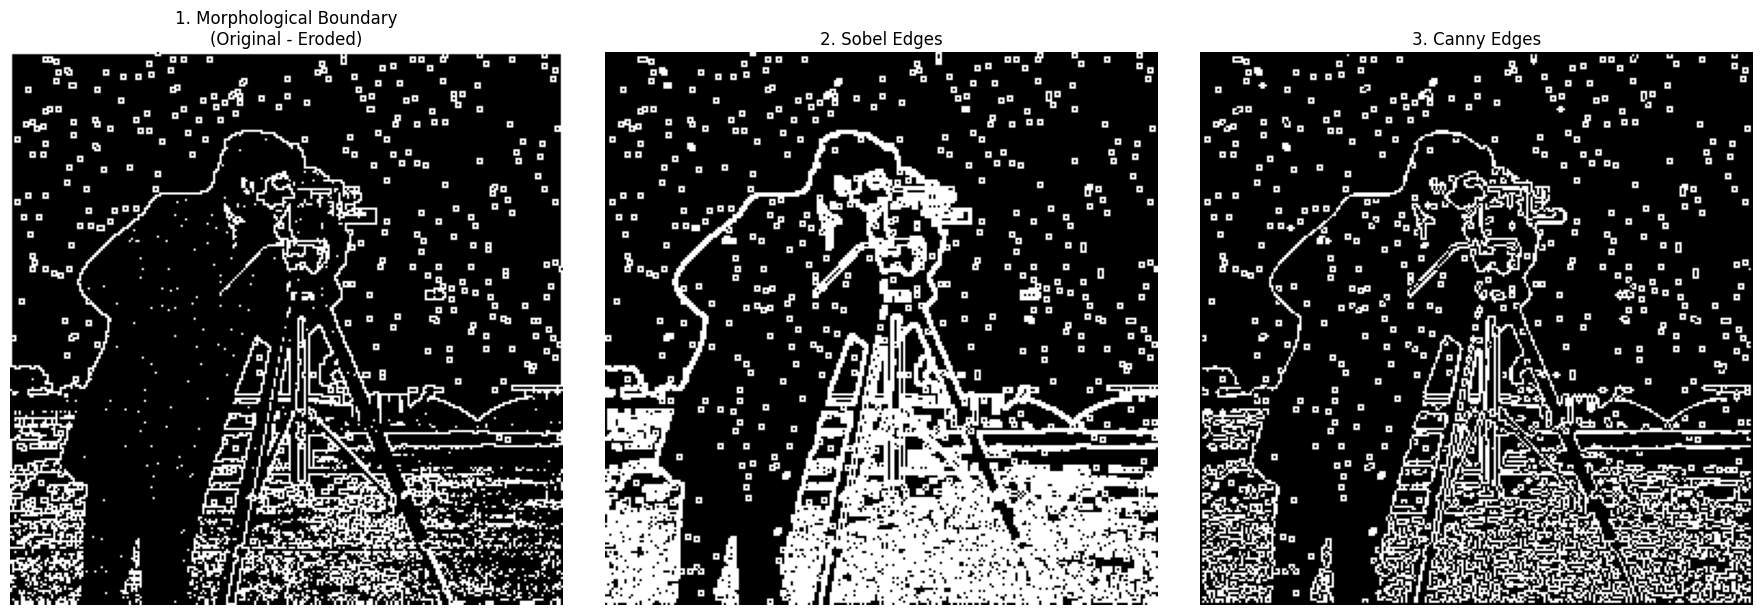

In [9]:
# Compare all three methods side by side
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("1. Morphological Boundary\n(Original - Eroded)")
plt.imshow(morphological_boundary, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Sobel Edges")
plt.imshow(sobel_edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Canny Edges")
plt.imshow(canny_edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

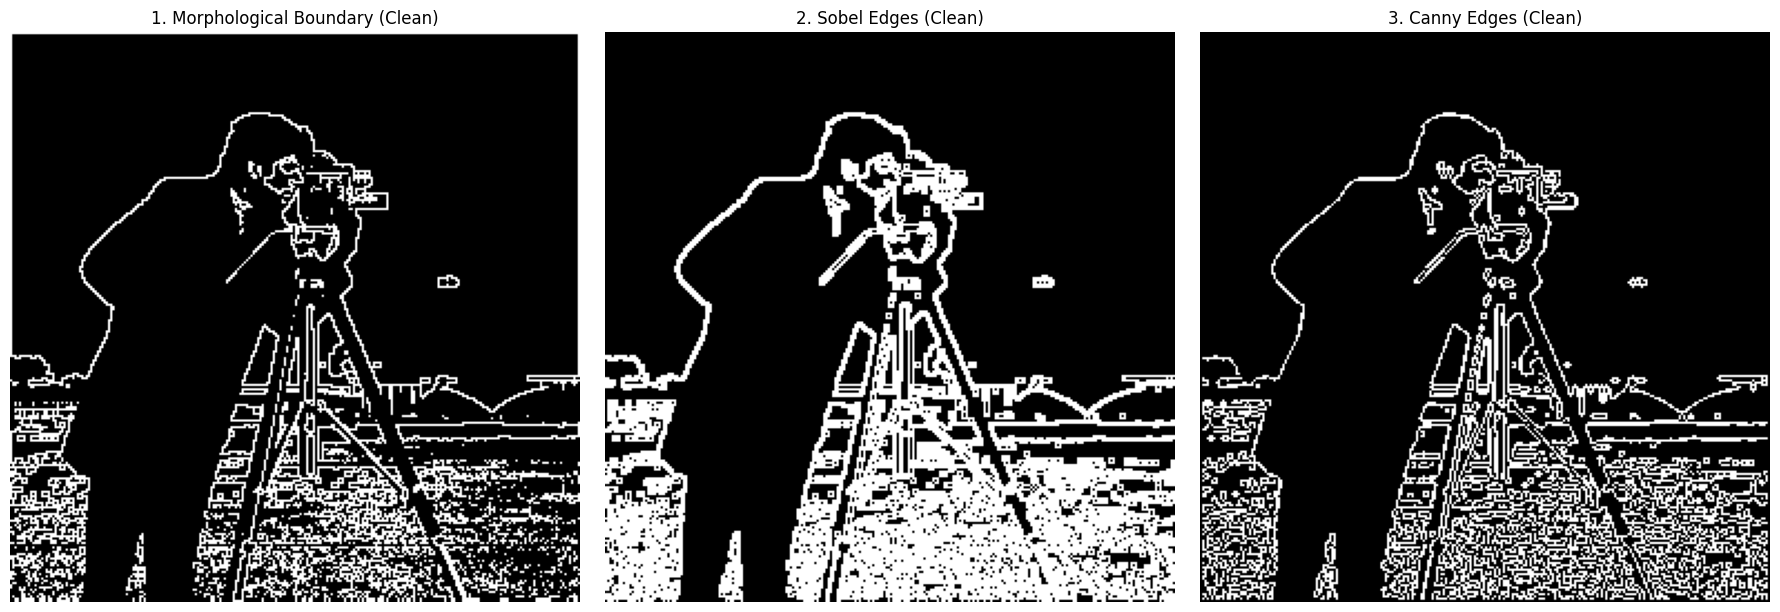

In [10]:
# We will use 'binary_img' which we created in Cell 1 (before adding noise)

# 1. Morphological Boundary (Clean)
eroded_clean = custom_erode(binary_img, kernel)
morph_boundary_clean = binary_img - eroded_clean

# 2. Sobel Edges (Clean)
sobel_x_clean = custom_convolve(binary_img * 255.0, Kx)
sobel_y_clean = custom_convolve(binary_img * 255.0, Ky)
sobel_mag_clean = np.hypot(sobel_x_clean, sobel_y_clean)
sobel_mag_clean = (sobel_mag_clean / sobel_mag_clean.max()) * 255.0
theta_clean = np.arctan2(sobel_y_clean, sobel_x_clean)
sobel_edges_clean = (sobel_mag_clean > 50).astype(np.uint8)

# 3. Canny Edges (Clean)
nms_clean = non_max_suppression(sobel_mag_clean, theta_clean)
canny_edges_clean = threshold_and_hysteresis(nms_clean, low_thresh_ratio=0.05, high_thresh_ratio=0.15)
canny_edges_clean = (canny_edges_clean == 255).astype(np.uint8)

# Display Clean Results Side-by-Side
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.title("1. Morphological Boundary (Clean)")
plt.imshow(morph_boundary_clean, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("2. Sobel Edges (Clean)")
plt.imshow(sobel_edges_clean, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("3. Canny Edges (Clean)")
plt.imshow(canny_edges_clean, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

In [11]:
def calculate_global_ssim(img1, img2):
    """
    Computes a simplified Global Structural Similarity Index (SSIM) between two images.
    """
    # Standard SSIM constants to stabilize the division with weak denominators
    K1 = 0.01
    K2 = 0.03
    L = 1 # Dynamic range for binary images (0 to 1)
    C1 = (K1 * L) ** 2
    C2 = (K2 * L) ** 2
    
    # Flatten arrays to compute global statistics
    img1_flat = img1.astype(np.float64).flatten()
    img2_flat = img2.astype(np.float64).flatten()
    
    # Means
    mu1 = np.mean(img1_flat)
    mu2 = np.mean(img2_flat)
    
    # Variances and Covariance
    sigma1_sq = np.var(img1_flat)
    sigma2_sq = np.var(img2_flat)
    sigma12 = np.cov(img1_flat, img2_flat)[0, 1]
    
    # SSIM Formula
    numerator = (2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)
    denominator = (mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2)
    
    return numerator / denominator

# Compute SSIM between the different edge detection methods on the clean image
ssim_morph_sobel = calculate_global_ssim(morph_boundary_clean, sobel_edges_clean)
ssim_morph_canny = calculate_global_ssim(morph_boundary_clean, canny_edges_clean)
ssim_sobel_canny = calculate_global_ssim(sobel_edges_clean, canny_edges_clean)

# Print the numerical comparison
print("--- Structural Similarity Index (SSIM) Comparison ---")
print(f"Morphological vs Sobel: {ssim_morph_sobel:.4f}")
print(f"Morphological vs Canny: {ssim_morph_canny:.4f}")
print(f"Sobel vs Canny:         {ssim_sobel_canny:.4f}")
print("-" * 51)
print("Note: Closer to 1.0 means highly similar. Closer to 0.0 means highly different.")

--- Structural Similarity Index (SSIM) Comparison ---
Morphological vs Sobel: 0.4475
Morphological vs Canny: 0.4019
Sobel vs Canny:         0.5907
---------------------------------------------------
Note: Closer to 1.0 means highly similar. Closer to 0.0 means highly different.
